## Exploratory Data Analysis on Retail Sales Data

### OIBSIP Data Analytics — Level 1 — Task 1

#### Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to identify sales patterns, customer behaviour, product performance, and actionable business insights.

#### Technologies Used

- Python
- Pandas
- Numpy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load & Inspect the Dataset

In [66]:
df = pd.read_csv("store_sales.csv", parse_dates=["TransactionDate"])
df.head()

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases,TransactionDate,Month,Quarter
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4,2025-03-18,2025-03,2025Q1
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4,2025-10-08,2025-10,2025Q4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3,2025-07-23,2025-07,2025Q3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4,2025-02-12,2025-02,2025Q1
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10,2025-03-10,2025-03,2025Q1


### Check the Column Names & Data Types

In [67]:
df.columns
df.dtypes

CustomerID                     int64
Age                            int64
Gender                           str
Category                         str
ItemPurchased                    str
Amount                       float64
Season                           str
PaymentMethod                    str
ItemRating                   float64
DiscountApplied(%)             int64
PreviousPurchases              int64
TransactionDate       datetime64[us]
Month                            str
Quarter                          str
dtype: object

### Check Dataset Size

In [68]:
df.shape

(5000, 14)

### 2. Check missing values

In [69]:
df.isnull().sum()

CustomerID            0
Age                   0
Gender                0
Category              0
ItemPurchased         0
Amount                0
Season                0
PaymentMethod         0
ItemRating            0
DiscountApplied(%)    0
PreviousPurchases     0
TransactionDate       0
Month                 0
Quarter               0
dtype: int64

### 3. Check Duplicates

In [70]:
df.duplicated().sum()

np.int64(0)

### 4. Descriptive statistics

In [71]:
numeric_columns = df.select_dtypes(include=np.number).columns

descriptive_statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

descriptive_statistics.round(2)

,Mean,Median,Mode,Standard Deviation
CustomerID,2500.50,2500.50,1.0,1443.52
Age,45.22,45.00,42.0,14.56
Amount,285.09,122.48,108.5,551.45
ItemRating,3.78,3.80,3.8,0.68
DiscountApplied(%),14.98,15.00,16.0,5.99
PreviousPurchases,5.01,5.00,5.0,2.19


### Observation

The purchase amount has a mean of approximately 285.09 and a median of approximately 122.48. Since the mean is considerably higher than the median, the purchase amount distribution is likely influenced by some high-value transactions.

### 5. Monthly sales trends

Monthly sales trends using line charts

In [72]:
monthly_sales = (
    df.groupby("Month")["Amount"]
      .sum()
      .sort_index()
)

monthly_sales

Month
2025-01    117786.94
2025-02     97138.90
2025-03    130215.37
2025-04    121909.70
2025-05    154805.07
2025-06    117041.47
2025-07    118783.20
2025-08    106882.90
2025-09    109783.21
2025-10    125622.53
2025-11     96555.14
2025-12    128928.18
Name: Amount, dtype: float64

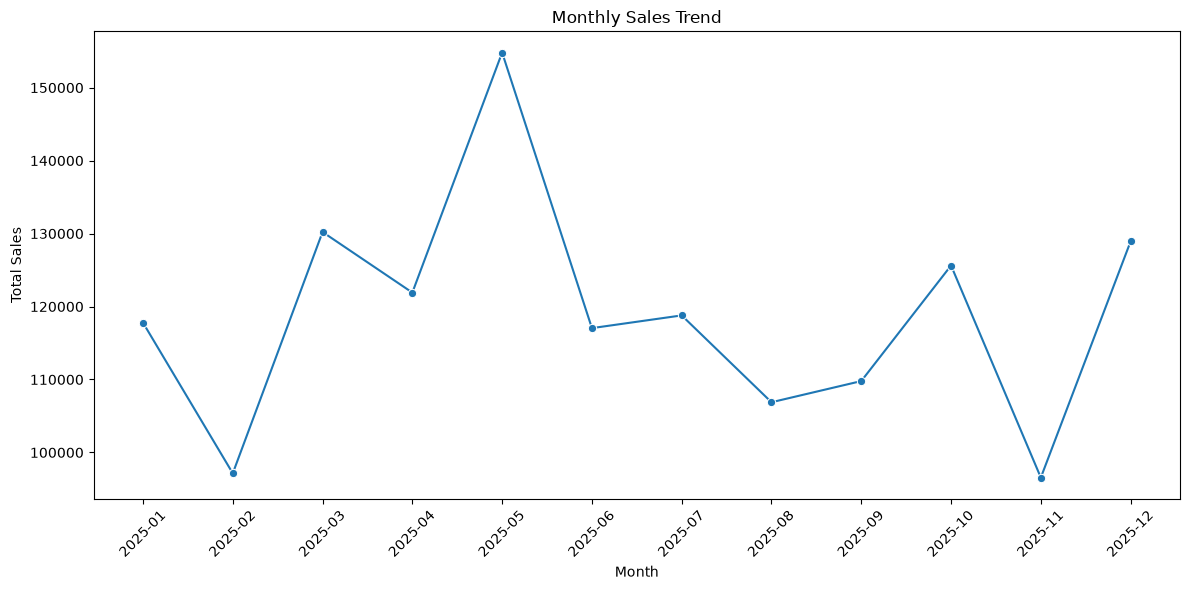

In [73]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

Monthly sales fluctuate throughout the year, with the highest sales in May and the lowest in November. Sales increase in March, October, and December, while a sharp decline occurs after May. Since the transaction dates are synthetic, these patterns should be treated as an analysis demonstration rather than actual historical sales trends.

### 6. Quarterly Sales Trend

In [74]:
quarterly_sales = (
    df.groupby("Quarter")["Amount"]
      .sum()
      .sort_index()
)

quarterly_sales

Quarter
2025Q1    345141.21
2025Q2    393756.24
2025Q3    335449.31
2025Q4    351105.85
Name: Amount, dtype: float64

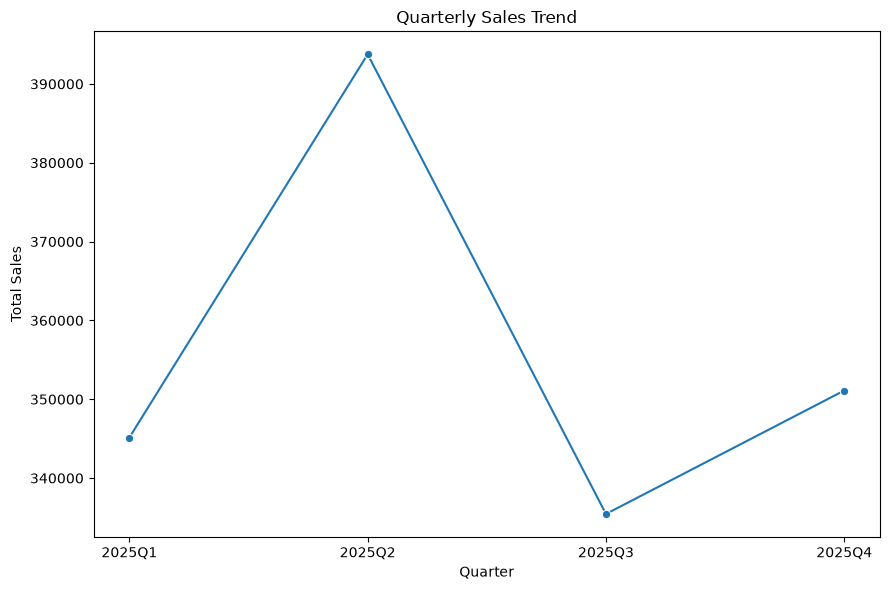

In [75]:
plt.figure(figsize=(9, 6))

sns.lineplot(
    x=quarterly_sales.index,
    y=quarterly_sales.values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Observation

Quarterly sales increased from Q1 to Q2, reaching the highest level in Q2. Sales then declined significantly in Q3 before recovering slightly in Q4. Since the transaction dates are synthetic, these quarterly patterns should be treated as a demonstration rather than actual historical sales performance.

### 7. Customer Demographics — Age Group

In [76]:
age_bins = [19, 24, 34, 44, 54, 64, 100]

age_labels = [
    "20-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_counts = df["AgeGroup"].value_counts().sort_index()

age_counts

AgeGroup
20-24     487
25-34     918
35-44    1010
45-54     985
55-64    1031
65+       569
Name: count, dtype: int64

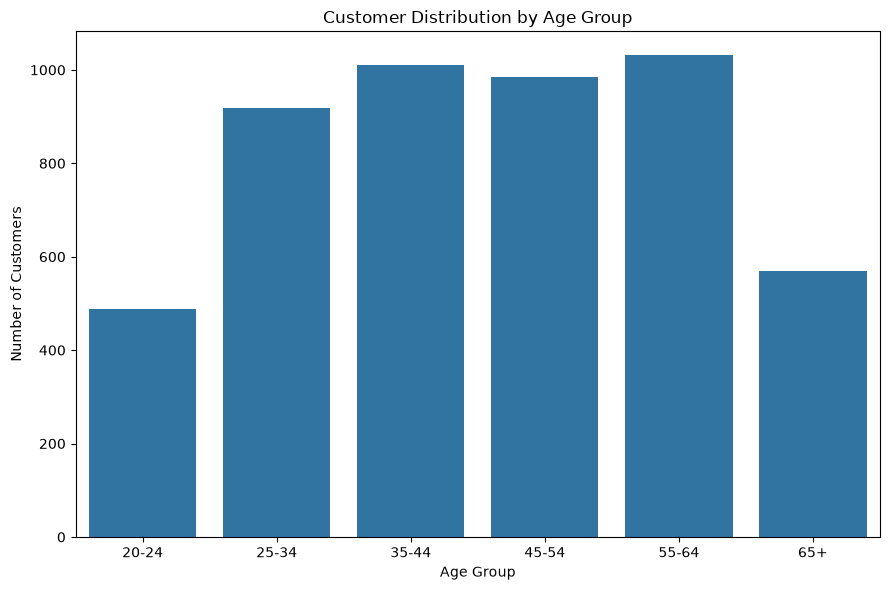

In [77]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=age_counts.index,
    y=age_counts.values
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Observation

The 55–64 age group represents the largest customer segment in the dataset. The 35–44 and 45–54 groups are also significant, indicating that middle-aged and older customers are important segments for the store.

### 8. Customer Demographics — Gender

In [78]:
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Female    2504
Male      2496
Name: count, dtype: int64

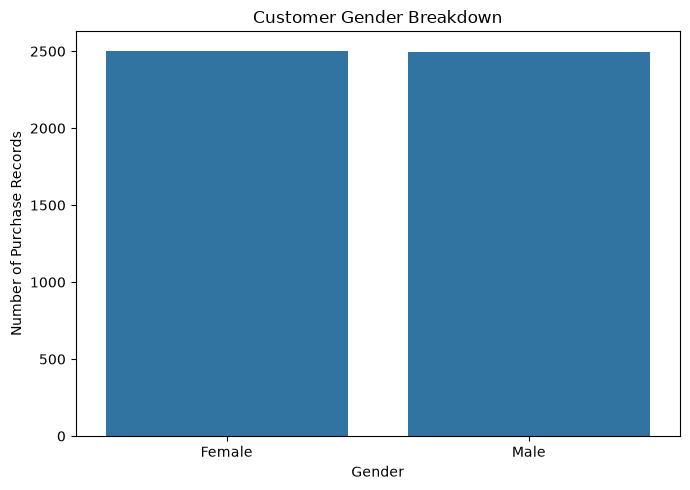

In [79]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Customer Gender Breakdown")
plt.xlabel("Gender")
plt.ylabel("Number of Purchase Records")

plt.tight_layout()
plt.show()

### Observation

The dataset contains 2,504 female purchase records and 2,496 male purchase records. Therefore, the customer distribution is almost perfectly balanced between the two genders.

### 9. Top 10 Best-Selling Products

In [80]:
top_products = df["ItemPurchased"].value_counts().head(10)

top_products

ItemPurchased
Sandals         339
Formal Shoes    324
Sneakers        320
Yoga Mat        283
Dumbbells       277
Football        275
Jeans           238
Skincare Kit    193
Makeup Set      176
Wallet          170
Name: count, dtype: int64

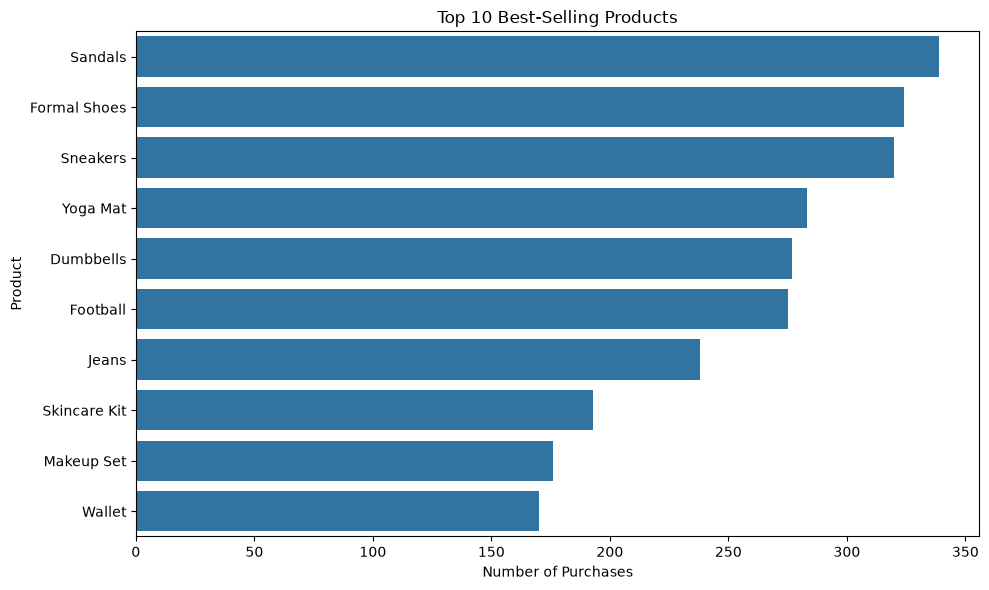

In [81]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Observation

Products such as Sandals, Formal Shoes, and Sneakers are among the most frequently purchased products. These high-volume products should receive sufficient inventory attention because stockouts could affect a significant number of transactions.

### 10. Product Analysis
Top 10 best-selling products; revenue by product category (bar chart)

In [82]:
category_revenue = (
    df.groupby("Category")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

category_revenue

Category
Electronics        895402.35
Footwear           141142.24
Sports             115598.11
Womens Clothing     61718.41
Mens Clothing       59680.43
Accessories         47633.83
Home                46374.22
Beauty              43887.06
Groceries           14015.96
Name: Amount, dtype: float64

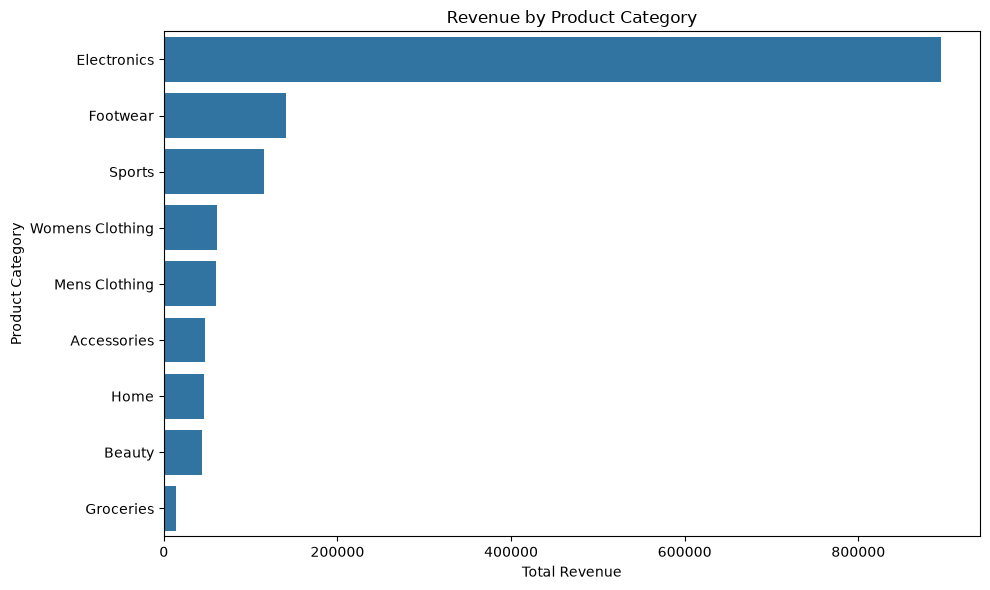

In [83]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Observation

Electronics generates the highest revenue among the product categories by a substantial margin. This makes electronics particularly important for inventory planning, revenue protection, and business strategy.

### 11. Correlation Heatmap
Correlation matrix between numerical variables

In [84]:
numeric_columns = df.select_dtypes(include=np.number).columns

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,CustomerID,Age,Amount,ItemRating,DiscountApplied(%),PreviousPurchases
CustomerID,1.000000,0.010128,0.010191,0.033162,0.012349,0.008740
Age,0.010128,1.000000,0.003056,0.003723,0.032820,0.029124
Amount,0.010191,0.003056,1.000000,0.000752,0.004291,-0.006010
ItemRating,0.033162,0.003723,0.000752,1.000000,0.158709,0.115781
DiscountApplied(%),0.012349,0.032820,0.004291,0.158709,1.000000,0.729560
PreviousPurchases,0.008740,0.029124,-0.006010,0.115781,0.729560,1.000000


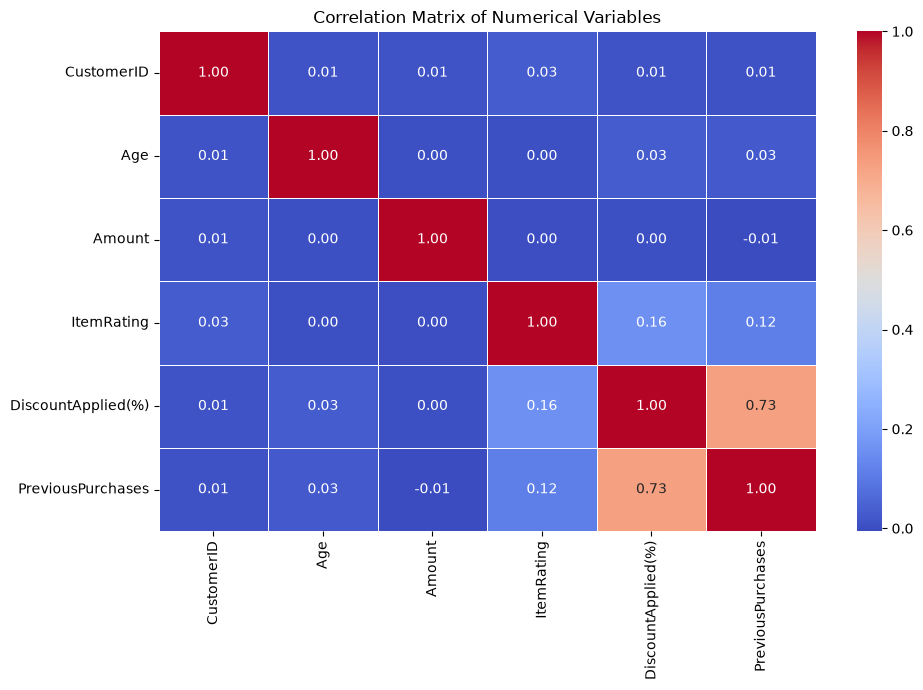

In [85]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

### Observation

The strongest positive relationship is between DiscountApplied(%) and PreviousPurchases, with a correlation of approximately 0.73. Purchase Amount has relatively weak linear relationships with most of the other numerical variables. Correlation indicates association between variables but does not prove that one variable causes another.

### 12. Additional Analysis
### Revenue by Category and Gender

This analysis compares revenue across product categories and gender to identify differences that may not be visible from the overall category revenue analysis.

In [86]:
gender_category_revenue = pd.pivot_table(
    df,
    values="Amount",
    index="Category",
    columns="Gender",
    aggfunc="sum",
    fill_value=0
)

gender_category_revenue

Gender,Female,Male
Category,,
Accessories,47633.83,0.00
Beauty,43887.06,0.00
Electronics,0.00,895402.35
Footwear,68669.12,72473.12
Groceries,7208.50,6807.46
Home,23208.36,23165.86
Mens Clothing,0.00,59680.43
Sports,23413.37,92184.74
Womens Clothing,61718.41,0.00


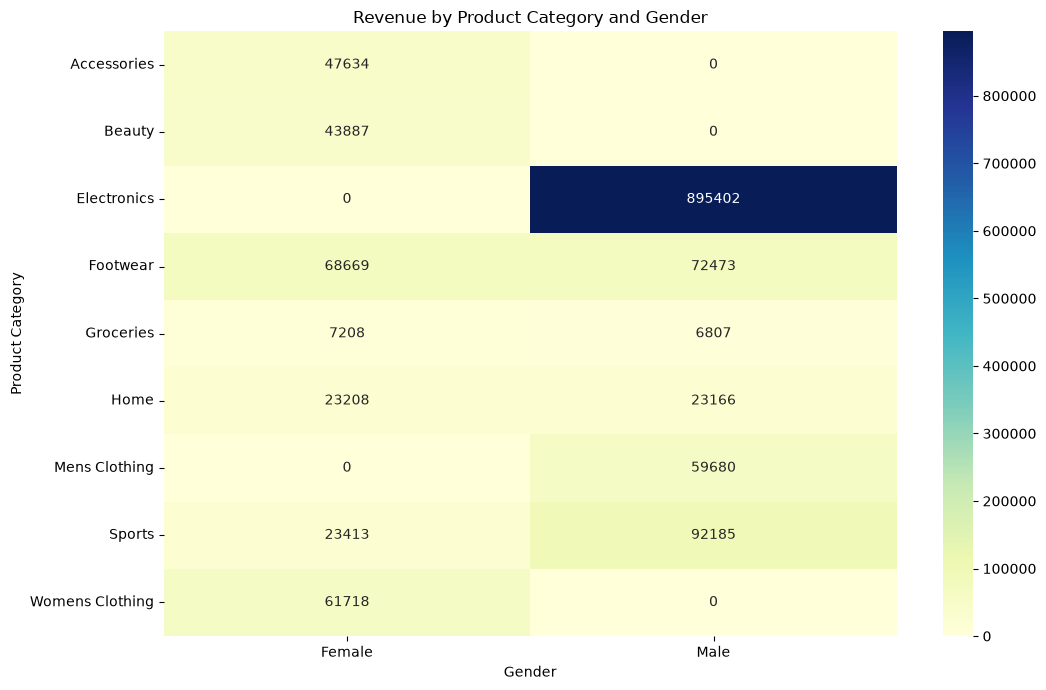

In [87]:
plt.figure(figsize=(11, 7))

sns.heatmap(
    gender_category_revenue,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Revenue by Product Category and Gender")
plt.xlabel("Gender")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Observation

The category-by-gender analysis reveals that differences in revenue between genders are strongly influenced by product-category composition. In this dataset, electronics revenue is associated with male records, while categories such as Beauty and Women's Clothing are associated with female records. Therefore, the overall revenue difference should not be interpreted as evidence that one gender inherently spends more than the other.

### 13. Payment Method Analysis

In [88]:
payment_summary = (
    df.groupby("PaymentMethod")["Amount"]
      .agg(["count", "sum", "mean"])
      .sort_values("sum", ascending=False)
)

payment_summary.round(2)

,count,sum,mean
PaymentMethod,,,
Card,4009,1366289.67,340.81
Cash on Delivery,991,59162.94,59.70


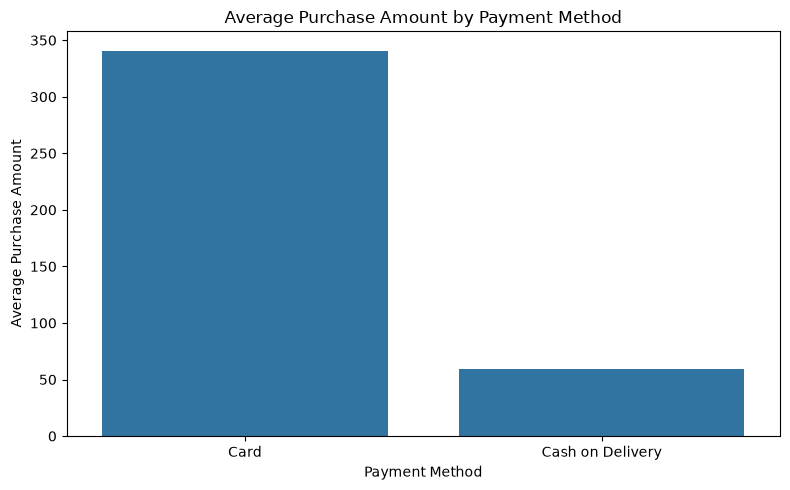

In [89]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_summary.index,
    y=payment_summary["mean"].values
)

plt.title("Average Purchase Amount by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Purchase Amount")

plt.tight_layout()
plt.show()

### Observation

Card payments account for a substantial share of transactions and have a higher average purchase amount than Cash on Delivery in this dataset. However, this is an observed association and does not mean that the payment method itself causes customers to spend more.

### 14. Actionable Business Recommendations

#### 1. Protect Electronics Inventory

Electronics generates exceptionally high revenue. The business should maintain sufficient stock of high-value electronics and closely monitor stockouts.

#### 2. Maintain Stock for High-Volume Products

Products such as footwear generate many purchase records. The business should ensure sufficient inventory for these high-volume products.

#### 3. Use Behaviour-Based Customer Segmentation

Customer marketing should consider age, previous purchases, product category, and purchase amount rather than relying only on gender.

#### 4. Test Targeted Discount Campaigns

The strong positive relationship between discount percentage and previous purchases suggests that discount strategies deserve further investigation. Controlled campaigns can determine whether discounts actually encourage repeat purchases.

#### 5. Collect Real Transaction Dates

Future retail datasets should contain genuine transaction dates. This would allow the business to conduct reliable monthly, quarterly, yearly, seasonal, and forecasting analyses.